### 1. Data preparation

This section covers the full pipeline from raw CSV to a clean, balanced, model-ready dataset. The steps are intentionally ordered:
load → drop → filter → balance → clean.
Each step operates on the output of the previous one to avoid data leakage or junk sneaking back in after balancing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_index = pd.read_csv('../Dataset/steam_reviews.csv', usecols=['app_name', 'recommended', 'language'])

print(f"Total rows in full dataset: {df_index.shape[0]}")
print(f"Unique games: {df_index['app_name'].nunique()}")
print(df_index['recommended'].value_counts(normalize=True).mul(100).round(1))
print("\n")

#LOAD
df = pd.read_csv('../Dataset/steam_reviews.csv',
                 usecols=['app_name', 'review', 'recommended',
                          'language', 'votes_helpful', 'votes_funny',
                          'weighted_vote_score', 'steam_purchase',
                          'received_for_free', 'written_during_early_access',
                          'author.playtime_forever', 'author.playtime_at_review'],
                 nrows=10_000_000)   #large pool so filtering still leaves plenty

print(f"Loaded:       {df.shape[0]:>7,} rows")

#DROP
df = df[df['language'] == 'english']
df = df.dropna(subset=['review', 'recommended'])
df = df[df['review'].str.strip() != '']   #catch whitespace-only reviews

print(f"After drop:   {df.shape[0]:>7,} rows")

Total rows in full dataset: 21747371
Unique games: 315
recommended
True     87.5
False    12.5
Name: proportion, dtype: float64


Loaded:       10,000,000 rows
After drop:   4,611,224 rows


In [8]:
#Checking what top games are available
game_counts = df_index.groupby('app_name').size().sort_values(ascending=False)

print(f"Total unique games: {len(game_counts)}")
print("\nTop 40 games by review count:")
print(game_counts.head(40).to_string())

Total unique games: 315

Top 40 games by review count:
app_name
PLAYERUNKNOWN'S BATTLEGROUNDS                  1644255
Grand Theft Auto V                             1019116
Tom Clancy's Rainbow Six Siege                  841918
Terraria                                        672815
Garry's Mod                                     655524
Rust                                            549074
Rocket League                                   498565
PAYDAY 2                                        487747
Among Us                                        485293
The Witcher 3: Wild Hunt                        469395
Dead by Daylight                                418897
ARK: Survival Evolved                           400009
Euro Truck Simulator 2                          387553
Stardew Valley                                  315717
The Elder Scrolls V: Skyrim                     294966
Wallpaper Engine                                292790
Monster Hunter: World                           290946
H

##### Class balancing

The raw Steam dataset has a 87.5% positive / 12.5% negative split.
Training directly on this would produce a biased model that defaults to predicting "recommended" for almost everything, this will make the model achieve high accuracy while being practically useless in unhandled enviroment.
I intentionally sample equal amounts of positive and negative reviews (25k each) to ensure the model learns genuine signals from both classes.

In [2]:
#FILTER
df['review_length'] = df['review'].str.split().str.len()

df = df[df['author.playtime_at_review'] > 300]     #played at least 5 hour
df = df[df['review_length'] >= 5]                 #at least 5 words
df = df[df['votes_funny'] <= df['votes_helpful']] #not a meme review

print(f"After filter: {df.shape[0]:>7,} rows")
print(f"  Positive: {(df['recommended']==True).sum():,}")
print(f"  Negative: {(df['recommended']==False).sum():,}")

#BALANCE
pos = df[df['recommended'] == True]
neg = df[df['recommended'] == False]

#Use whichever class is smaller as the cap this avoids errors if negatives < 25k
n = min(len(pos), len(neg), 25_000)

pos_sample = pos.sample(n=n, random_state=42)
neg_sample = neg.sample(n=n, random_state=42)

df = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset: {df.shape[0]:,} rows")
print(df['recommended'].value_counts())
df = df.drop(columns=['language'])

After filter: 2,452,707 rows
  Positive: 2,272,519
  Negative: 180,188

Final dataset: 50,000 rows
recommended
False    25000
True     25000
Name: count, dtype: int64


##### Quality filtering

- `playtime_at_review > 300` min: requires at least 5 hours played which eliminates refund-window reviews and drive-by opinions from people who barely touched the game contents
- `review_length >= 5` words: removes single-word or empty responses
- `votes_funny <= votes_helpful`: filters meme reviews that the community flagged as jokes (troll) rather than genuine feedback

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Custom stopwords — standard list minus negations which is needed for not-reccomended reviews
base_stopwords = set(stopwords.words('english'))
negations = {'not', 'no', 'nor', 'never', "don't", "doesn't", "didn't",
             "won't", "wouldn't", "can't", "cannot", "isn't", "aren't",
             "wasn't", "weren't", "hardly", "barely", "scarcely"}
custom_stopwords = base_stopwords - negations

lemmatizer = WordNetLemmatizer()

def clean_review(text):
    text = text.lower() #lowercase
    text = re.sub(r'<.*?>', ' ', text) #remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text) #remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) #remove non-ASCII
    text = re.sub(r'[^a-z\s]', ' ', text) #remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip() #strip extra whitespace
    
    tokens = text.split()
    tokens = [t for t in tokens if t not in custom_stopwords] #remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] #lemmatize
    
    return ' '.join(tokens)

#Apply to the dataframe
df['cleaned_review'] = df['review'].apply(clean_review)

print("Sample output:")
print(df[['review', 'cleaned_review']].head(3))

#Make sure nothing went empty after cleaning
df['cleaned_length'] = df['cleaned_review'].str.split().str.len()
print(f"Reviews that became empty after cleaning: {(df['cleaned_length'] == 0).sum()}")

#Drop any that did
df = df[df['cleaned_length'] > 0]
print(f"Rows remaining: {df.shape[0]:,}")

Sample output:
                                              review  \
0  Meh, just a bunch of nakeds. If youre into tha...   
1  First Impression Gameplay: https://www.youtube...   
2  This is one of the best games I ever played ! ...   

                                      cleaned_review  
0                       meh bunch nakeds youre guess  
1  first impression gameplay stardew valley one g...  
2  one best game ever played great awesome fantas...  
Reviews that became empty after cleaning: 127
Rows remaining: 49,873


##### Text cleaning

Raw Steam reviews contain significant noise such as HTML tags, URLs, emoji, non-English characters, punctuation, and extremely common words that carry no sentiment signal. I apply the following pipeline to each review:

- Lowercase: normalizes casing so "Great" and "great" are treated as the same word
- Remove HTML tags: Steam allows `<br>` and other tags in reviews
- Remove URLs: links carry no sentiment signal
- Remove non-ASCII: catches emoji and foreign characters that slipped past the language filter
- Remove punctuation and numbers: mostly noise for TF-IDF; sentiment lives in the words
- Remove stopwords: common words like "the", "a", "is" filtered via custom NLTK list
- Lemmatization: reduces words to base form so "running" and "runs" both count as "run"

Negations (`not`, `never`, `can't`, etc.) are deliberately kept by subtracting them from the standard stopword list. Removing them would flip meaning. For example "not good" would become "good" and actively mislead the model.

Numbers are removed intentionally. A score like `9/10` in a review carries no learnable signal for TF-IDF since the same numbers appear in both positive and negative reviews with no consistent pattern. The sentiment is in the surrounding words, not the rating itself.

### 2. Vectorization

With 49,873 clean, balanced English reviews in hand, the next step is converting text into numbers the model can learn from.

I use **TF-IDF** (Term Frequency–Inverse Document Frequency), which represents each review as a vector of word importance scores. Words that appear frequently in one review but rarely across the whole dataset get higher scores — this naturally surfaces meaningful terms like "crash", "optimization", or "masterpiece" over generic filler.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

#VECTORIZE
tfidf = TfidfVectorizer(
    max_features=15000,   #keep top 15k most meaningful words
    min_df=5,             #ignore words appearing in fewer than 5 reviews
    max_df=0.95,          #ignore words appearing in more than 95% of reviews
    ngram_range=(1, 2),   #include single words AND two-word pairs
    sublinear_tf=True     #compress term frequency scale (log normalization)
)

X = tfidf.fit_transform(df['cleaned_review'])
y = df['recommended'].astype(int)   #True→1, False→0

print(f"Matrix shape: {X.shape}")
print(f"Total features (unique terms): {X.shape[1]}")
print(f"Label distribution: {y.value_counts().to_dict()}")

#TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set:   {X_train.shape[0]:,} rows")
print(f"Test set:       {X_test.shape[0]:,} rows")

Matrix shape: (49873, 15000)
Total features (unique terms): 15000
Label distribution: {0: 24940, 1: 24933}

Training set:   39,898 rows
Test set:       9,975 rows


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

#TRAIN BOTH MODELS
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

#EVALUATE
for name, model in [('Logistic Regression', lr), ('Naive Bayes', nb)]:
    y_pred = model.predict(X_test)
    print(f"\n{'─'*40}")
    print(f"{name}")
    print(f"{'─'*40}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=['Not recommended', 'Recommended']))


────────────────────────────────────────
Logistic Regression
────────────────────────────────────────
Accuracy: 0.8736
                 precision    recall  f1-score   support

Not recommended       0.88      0.87      0.87      4988
    Recommended       0.87      0.88      0.87      4987

       accuracy                           0.87      9975
      macro avg       0.87      0.87      0.87      9975
   weighted avg       0.87      0.87      0.87      9975


────────────────────────────────────────
Naive Bayes
────────────────────────────────────────
Accuracy: 0.8593
                 precision    recall  f1-score   support

Not recommended       0.84      0.89      0.86      4988
    Recommended       0.88      0.83      0.85      4987

       accuracy                           0.86      9975
      macro avg       0.86      0.86      0.86      9975
   weighted avg       0.86      0.86      0.86      9975



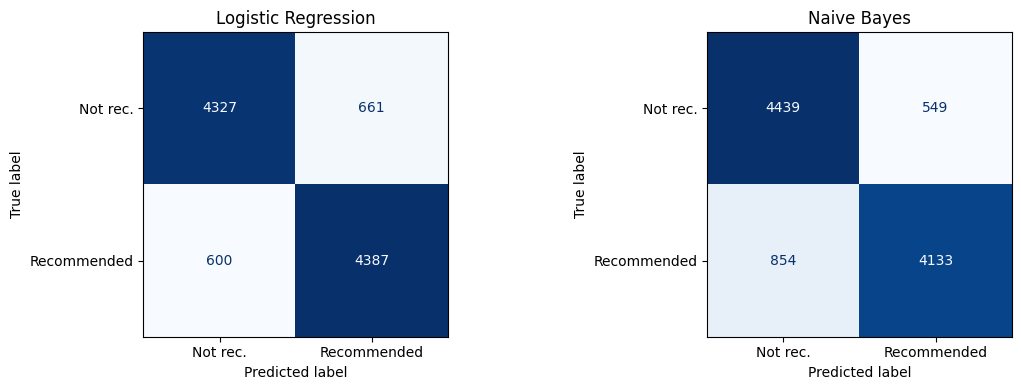

In [6]:
#CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, [('Logistic Regression', lr), ('Naive Bayes', nb)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not rec.', 'Recommended'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../output/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Top predictive words

Here we look inside the Logistic Regression model to understand *why* it makes predictions, not just *what* it predicts. The model's coefficient vector has one value per TF-IDF feature (word/bigram). A large positive coefficient means the term strongly pushes toward **Recommended**; a large 
negative one pushes toward **Not recommended**.
This is one of the key advantages of Logistic Regression over black-box models, the weights are directly interpretable as feature importance.

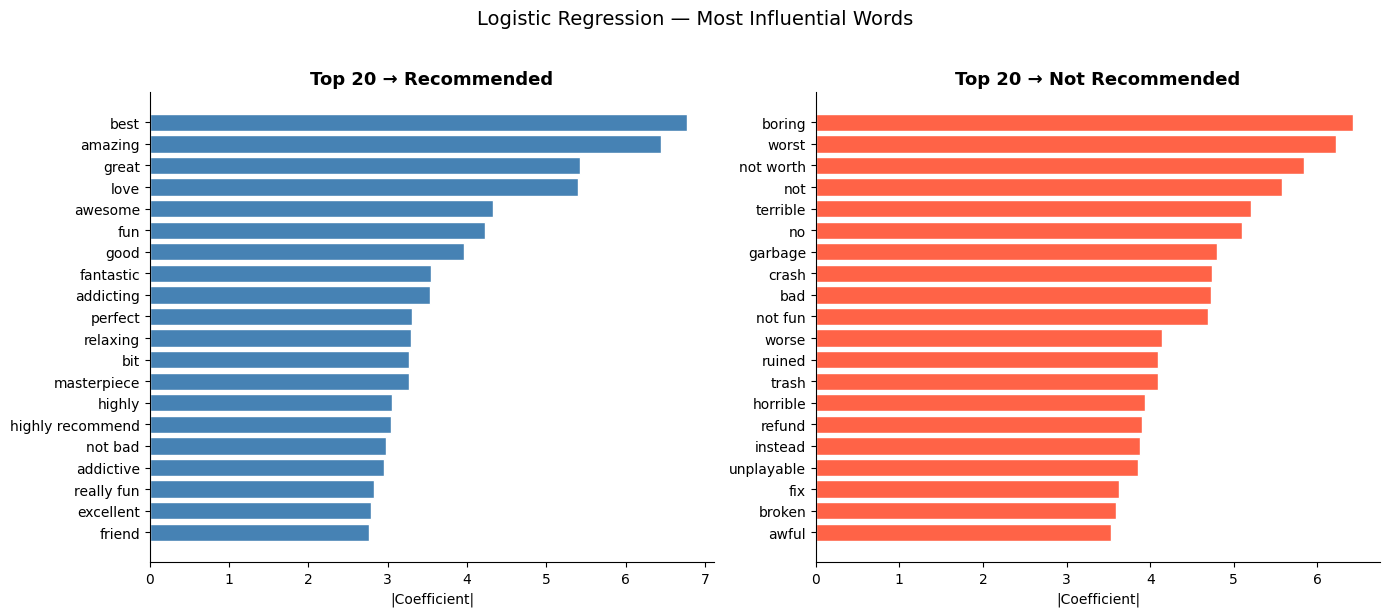

In [7]:
#Logistic Regression coefficients
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]   # shape: (15000,)

#Sort by coefficient value
top_n = 20
top_pos_idx = coefs.argsort()[-top_n:][::-1]   #most positive → Recommended
top_neg_idx = coefs.argsort()[:top_n]           #most negative → Not recommended

top_pos_words = [(feature_names[i], coefs[i]) for i in top_pos_idx]
top_neg_words = [(feature_names[i], coefs[i]) for i in top_neg_idx]

#Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, words, title, color in zip(
    axes,
    [top_pos_words, top_neg_words],
    ['Top 20 → Recommended', 'Top 20 → Not Recommended'],
    ['steelblue', 'tomato']
):
    labels, vals = zip(*words)
    bars = ax.barh(range(len(labels)), [abs(v) for v in vals], color=color, edgecolor='white')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()   #highest coefficient at top
    ax.set_xlabel('|Coefficient|')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Logistic Regression — Most Influential Words', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Selected game sentiment breakdown

We apply the trained model to five iconic Steam titles spanning different genres to compare how community sentiment varies and how well the model's predictions align with the actual Steam thumbs-up ratio.

| Game | Genre | Why interesting |
|---|---|---|
| Grand Theft Auto V | Open world | Massive player base, love-it-or-hate-it online |
| The Elder Scrolls V: Skyrim | RPG | Legendary status but also meme-level "re-release fatigue" |
| PLAYERUNKNOWN'S BATTLEGROUNDS | Battle royale | Polarising early-access history, cheating controversies |
| Sid Meier's Civilization VI | Strategy | Niche audience, very opinionated reviews |
| Cities: Skylines | City builder | Widely praised as the definitive city builder |

We go back to the **full unbalanced dataset**, load only these five games via chunked streaming, apply the same quality filters as Section 1, then run the trained TF-IDF + Logistic Regression pipeline. We use `tfidf.transform()` and not `fit_transform()` to avoid leaking new vocabulary into the trained model.

Rows loaded: 935,921
app_name
Grand Theft Auto V               319751
The Elder Scrolls V: Skyrim      160233
PLAYERUNKNOWN'S BATTLEGROUNDS    317846
Sid Meier's Civilization VI       68025
Cities: Skylines                  70066
Name: count, dtype: int64
After quality filter: 542,882 rows
app_name
Grand Theft Auto V               164787
The Elder Scrolls V: Skyrim      107568
PLAYERUNKNOWN'S BATTLEGROUNDS    181174
Sid Meier's Civilization VI       44370
Cities: Skylines                  44983
Name: count, dtype: int64
Predictions done: 540,265 rows
                         n  actual_pos  predicted_pos  agreement
GTA V             164278.0        64.5           54.5       79.4
Skyrim            107317.0        92.8           83.0       86.8
PUBG              179381.0        54.3           42.7       79.8
Civ VI             44341.0        77.4           60.0       79.6
Cities: Skylines   44948.0        92.9           82.7       87.7


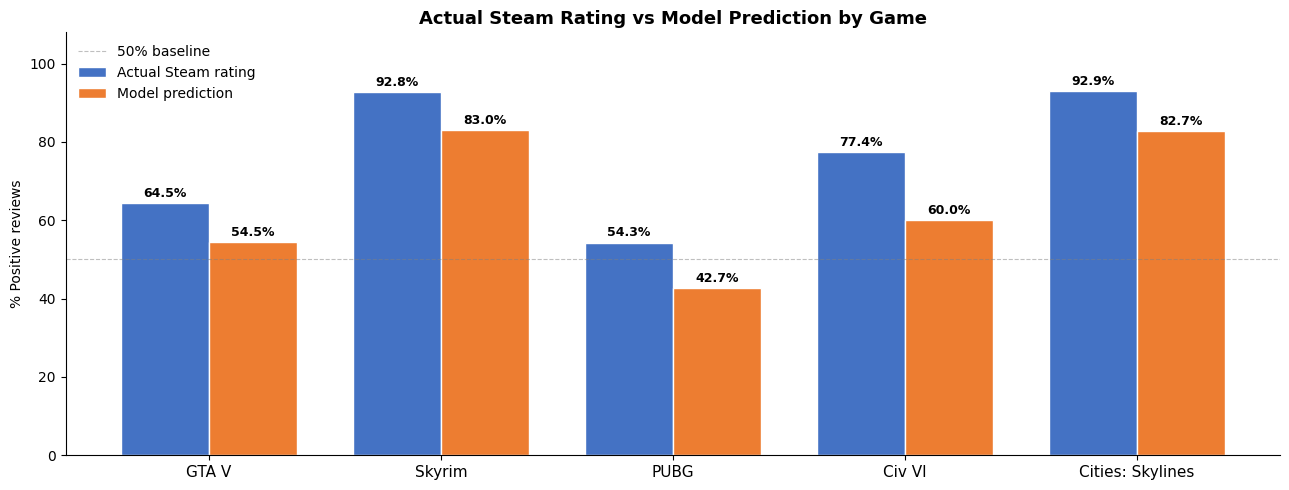

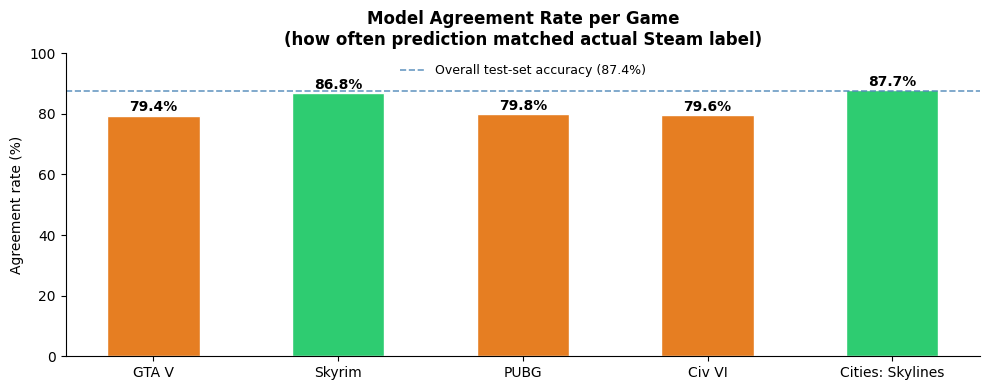

Game                      Reviews    Actual+   Predicted+   Agreement
────────────────────────────────────────────────────────────────────
GTA V                     164,278      64.5%        54.5%       79.4%
Skyrim                    107,317      92.8%        83.0%       86.8%
PUBG                      179,381      54.3%        42.7%       79.8%
Civ VI                     44,341      77.4%        60.0%       79.6%
Cities: Skylines           44,948      92.9%        82.7%       87.7%


In [9]:
#Target games
target_games = [
    'Grand Theft Auto V',
    'The Elder Scrolls V: Skyrim',
    "PLAYERUNKNOWN'S BATTLEGROUNDS",
    "Sid Meier's Civilization VI",
    'Cities: Skylines',
]

#Short display labels for charts
short_names = ['GTA V', 'Skyrim', 'PUBG', 'Civ VI', 'Cities: Skylines']

#Stream the CSV to only keep rows for these 5 games
chunks = pd.read_csv(
    '../Dataset/steam_reviews.csv',
    usecols=['app_name', 'review', 'recommended', 'language',
             'author.playtime_at_review', 'votes_helpful', 'votes_funny'],
    chunksize=500_000
)

game_dfs = []
for chunk in chunks:
    mask = chunk['app_name'].isin(target_games) & (chunk['language'] == 'english')
    game_dfs.append(chunk[mask])

df_games = pd.concat(game_dfs).reset_index(drop=True)
print(f"Rows loaded: {df_games.shape[0]:,}")
print(df_games['app_name'].value_counts().reindex(target_games))

#Apply the same quality filter as Section 1
df_games['review_length'] = df_games['review'].str.split().str.len()
df_games = df_games.dropna(subset=['review', 'recommended'])
df_games = df_games[df_games['review'].str.strip() != '']
df_games = df_games[df_games['author.playtime_at_review'] > 300]
df_games = df_games[df_games['review_length'] >= 5]
df_games = df_games[df_games['votes_funny'] <= df_games['votes_helpful']]

print(f"After quality filter: {df_games.shape[0]:,} rows")
print(df_games['app_name'].value_counts().reindex(target_games))

#Clean + Predict. Transform only, never refit the vectorizer
df_games['cleaned_review'] = df_games['review'].apply(clean_review)
df_games = df_games[df_games['cleaned_review'].str.split().str.len() > 0].reset_index(drop=True)

X_games = tfidf.transform(df_games['cleaned_review'])
df_games['predicted']       = lr.predict(X_games)
df_games['predicted_label'] = df_games['predicted'].map({1: 'Recommended', 0: 'Not recommended'})
df_games['actual_label']    = df_games['recommended'].map({True: 'Recommended', False: 'Not recommended'})

print(f"Predictions done: {len(df_games):,} rows")

#Summary per game
summary = (
    df_games.groupby('app_name')
    .apply(lambda g: pd.Series({
        'n':              len(g),
        'actual_pos':     (g['actual_label'] == 'Recommended').mean() * 100,
        'predicted_pos':  (g['predicted_label'] == 'Recommended').mean() * 100,
        'agreement':      (g['actual_label'] == g['predicted_label']).mean() * 100,
    }))
    .reindex(target_games)
)
summary.index = short_names   #Swap to display names for all charts below

print(summary.round(1).to_string())

#Chart 1 — Grouped bar: Actual vs Predicted % positive per game
x     = range(len(short_names))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))

bars_actual    = ax.bar([i - width/2 for i in x], summary['actual_pos'],
                        width, label='Actual Steam rating', color='#4472C4', edgecolor='white')
bars_predicted = ax.bar([i + width/2 for i in x], summary['predicted_pos'],
                        width, label='Model prediction',    color='#ED7D31', edgecolor='white')

#Value labels on bars
for bar in list(bars_actual) + list(bars_predicted):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, 108)
ax.set_ylabel('% Positive reviews')
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5, label='50% baseline')
ax.legend(frameon=False)
ax.set_title('Actual Steam Rating vs Model Prediction by Game', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../output/game_sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#Chart 2 — Model agreement rate per game (how often prediction matched the actual label)
fig, ax = plt.subplots(figsize=(10, 4))

colors_agree = ['#2ecc71' if v >= 85 else '#e67e22' if v >= 75 else '#e74c3c'
                for v in summary['agreement']]

bars = ax.bar(short_names, summary['agreement'], color=colors_agree, edgecolor='white', width=0.5)

for bar, val in zip(bars, summary['agreement']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 100)
ax.axhline(87.4, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.8,
           label='Overall test-set accuracy (87.4%)')
ax.set_ylabel('Agreement rate (%)')
ax.set_title('Model Agreement Rate per Game\n(how often prediction matched actual Steam label)',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../output/game_agreement_rate.png', dpi=150, bbox_inches='tight')
plt.show()

#PRINTED SUMMARY TABLE
print(f"{'Game':<22} {'Reviews':>10} {'Actual+':>10} {'Predicted+':>12} {'Agreement':>11}")
print('─' * 68)
for name, row in summary.iterrows():
    print(f"{name:<22} {int(row['n']):>10,} {row['actual_pos']:>9.1f}% "
          f"{row['predicted_pos']:>11.1f}% {row['agreement']:>10.1f}%")

### 5. Interactive demo

Type any review and get an instant prediction with a confidence score, powered by the trained Logistic Regression + TF-IDF pipeline above.

In [10]:
import gradio as gr

def predict_sentiment(text: str):
    if not text.strip():
        return "Please enter a review.", ""
    
    cleaned = clean_review(text)
    vec     = tfidf.transform([cleaned])
    pred    = lr.predict(vec)[0]
    proba   = lr.predict_proba(vec)[0]
    
    label      = "Recommended" if pred == 1 else "Not Recommended"
    confidence = proba[pred]
    detail     = (f"Confidence: {confidence*100:.1f}%\n"
                  f"P(Recommended): {proba[1]*100:.1f}%  |  "
                  f"P(Not recommended): {proba[0]*100:.1f}%")
    return label, detail

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Paste a Steam review here…", label="Review"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence breakdown"),
    ],
    title="Steam Review Sentiment Analyser",
    description="Logistic Regression + TF-IDF trained on 50k balanced Steam reviews.",
    examples=[
        ["Absolutely stunning game. The world design and story are masterpieces."],
        ["Complete waste of money. Crashes every 10 minutes and support is useless."],
        ["It's okay. Fun for a few hours but gets repetitive. Nothing special."],
    ],
    flagging_mode="never",
)

demo.launch()

c:\Users\M S I\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
